# Model Training — ml-25m

Full training pipeline: UserCF is dropped; we use SVD, Sparse ItemCF, Content-Based, Hybrid, and IMDb Boost.

Steps:
1. Load cleaned data
2. Sparsity analysis
3. 70/15/15 split (Train / Valid / Test)
4. SVD GridSearch on valid set
5. Sparse ItemCF (NearestNeighbors)
6. Content-Based (cold-start)
7. Hybrid SVD + ItemCF — find best alpha
8. IMDb Score Boost — find best beta
9. Final evaluation on test set
10. Save all models

Requires: `Data_Processing.ipynb` completed — files present in `data/cleaning/`


## 1. Load Data

In [1]:
import os, warnings, time, itertools
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import normalize
from surprise import SVD, Dataset, Reader
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

print('Loading cleaned data...')
df_ratings  = pd.read_parquet('data/cleaning/ratings_cleaning.parquet')
df_metadata = pd.read_parquet('data/cleaning/movies_metadata.parquet')
df_features = pd.read_parquet('data/cleaning/model_features.parquet')

df_ratings['userId']  = df_ratings['userId'].astype(int)
df_ratings['movieId'] = df_ratings['movieId'].astype(int)
df_ratings['rating']  = df_ratings['rating'].astype(float)

print(f'Ratings : {len(df_ratings):,}')
print(f'Users   : {df_ratings["userId"].nunique():,}')
print(f'Movies  : {df_ratings["movieId"].nunique():,}')
print(f'Rating range: {df_ratings["rating"].min()} to {df_ratings["rating"].max()}')
print(f'Feature columns: {df_features.shape[1]}')

Loading cleaned data...
Ratings : 24,945,870
Users   : 162,541
Movies  : 32,720
Rating range: 0.5 to 5.0
Feature columns: 185


## 2. Sparsity Analysis

In [2]:
n_users  = df_ratings['userId'].nunique()
n_movies = df_ratings['movieId'].nunique()
n_rat    = len(df_ratings)
sparsity = 1 - n_rat / (n_users * n_movies)

print(f'Users   : {n_users:,}')
print(f'Movies  : {n_movies:,}')
print(f'Ratings : {n_rat:,}')
print(f'Sparsity: {sparsity:.5f} ({sparsity*100:.3f}%)')
print(f'Dense matrix would be: {n_users*n_movies*8/1e9:.1f} GB')
print('Using sparse matrix + NearestNeighbors for ItemCF to avoid OOM.')

Users   : 162,541
Movies  : 32,720
Ratings : 24,945,870
Sparsity: 0.99531 (99.531%)
Dense matrix would be: 42.5 GB
Using sparse matrix + NearestNeighbors for ItemCF to avoid OOM.


## 3. Train / Valid / Test Split (70/15/15)

Temporal split per user: first 70% of each user's ratings go to train, next 15% to valid, last 15% to test.

In [3]:
from sklearn.model_selection import train_test_split

if 'timestamp' not in df_ratings.columns:
    df_ratings['timestamp'] = np.arange(len(df_ratings))

df_sorted = df_ratings.sort_values(['userId', 'timestamp']).reset_index(drop=True)

train_list, valid_list, test_list = [], [], []

for uid, grp in tqdm(df_sorted.groupby('userId'), desc='Splitting by user'):
    n = len(grp)
    if n < 3:
        train_list.append(grp)
        continue
    n_train = max(1, int(n * 0.70))
    n_valid = max(1, int(n * 0.15))
    train_list.append(grp.iloc[:n_train])
    valid_list.append(grp.iloc[n_train:n_train + n_valid])
    test_list.append(grp.iloc[n_train + n_valid:])

df_train = pd.concat(train_list).reset_index(drop=True)
df_valid = pd.concat(valid_list).reset_index(drop=True) if valid_list else pd.DataFrame(columns=df_sorted.columns)
df_test  = pd.concat(test_list).reset_index(drop=True)  if test_list  else pd.DataFrame(columns=df_sorted.columns)

total = len(df_train) + len(df_valid) + len(df_test)
print(f'Train : {len(df_train):,} ({len(df_train)/total:.1%})')
print(f'Valid : {len(df_valid):,} ({len(df_valid)/total:.1%})')
print(f'Test  : {len(df_test):,}  ({len(df_test)/total:.1%})')

df_train.to_csv(MODELS_DIR / 'df_train.csv', index=False)
df_test.to_csv(MODELS_DIR / 'df_test.csv', index=False)


Splitting by user:   0%|          | 0/162541 [00:00<?, ?it/s]

Train : 17,389,524 (69.7%)
Valid : 3,667,830 (14.7%)
Test  : 3,888,516  (15.6%)


## 4. Build Sparse User-Item Matrix

In [4]:
user_ids     = df_train['userId'].unique()
movie_ids    = df_train['movieId'].unique()
user_to_idx  = {u: i for i, u in enumerate(user_ids)}
movie_to_idx = {m: i for i, m in enumerate(movie_ids)}
idx_to_user  = {i: u for u, i in user_to_idx.items()}
idx_to_movie = {i: m for m, i in movie_to_idx.items()}

rows = df_train['userId'].map(user_to_idx)
cols = df_train['movieId'].map(movie_to_idx)
R    = csr_matrix((df_train['rating'], (rows, cols)),
                  shape=(len(user_ids), len(movie_ids)),
                  dtype=np.float32)

print(f'R matrix shape  : {R.shape}')
print(f'Non-zero entries: {R.nnz:,}')
print(f'Density         : {R.nnz/np.prod(R.shape):.5f}')
print(f'Memory (sparse) : {R.data.nbytes/1e6:.1f} MB')

R matrix shape  : (162541, 32199)
Non-zero entries: 17,389,524
Density         : 0.01853
Memory (sparse) : 69.6 MB


## 5. SVD GridSearch

Grid search over hyperparameters, evaluated on valid set by RMSE.  
Best params are then used to retrain on Train + Valid before final test evaluation.

In [5]:
r_min = df_ratings['rating'].min()
r_max = df_ratings['rating'].max()
reader = Reader(rating_scale=(r_min, r_max))

surprise_train    = Dataset.load_from_df(df_train[['userId', 'movieId', 'rating']], reader)
surprise_trainset = surprise_train.build_full_trainset()

valid_tuples = list(zip(df_valid['userId'], df_valid['movieId'], df_valid['rating']))
if len(valid_tuples) > 50000:
    import random; random.seed(42)
    valid_tuples = random.sample(valid_tuples, 50000)

print(f'Surprise trainset : {surprise_trainset.n_ratings:,} ratings')
print(f'Valid tuples      : {len(valid_tuples):,}')

Surprise trainset : 17,389,524 ratings
Valid tuples      : 50,000


In [6]:
# TOGGLE FAST GRIDSEARCH FOR ACADEMIC RUNS AND SWEEPS
FAST_GRID = True  # Set to False to run the full exhaustive 108-combination grid (takes ~3.6 hours)

if FAST_GRID:
    print('Using FAST_GRID mode (4 combinations, takes ~8 minutes)...')
    PARAM_GRID = {
        'n_factors' : [100, 150],
        'n_epochs'  : [30, 50],
        'lr_all'    : [0.01],
        'reg_all'   : [0.05],
    }
else:
    print('Using FULL_GRID mode (108 combinations, takes ~3.6 hours)...')
    PARAM_GRID = {
        'n_factors' : [50, 100, 150, 200],
        'n_epochs'  : [20, 30, 50],
        'lr_all'    : [0.002, 0.005, 0.01],
        'reg_all'   : [0.02, 0.05, 0.1],
    }

all_combinations = list(itertools.product(
    PARAM_GRID['n_factors'],
    PARAM_GRID['n_epochs'],
    PARAM_GRID['lr_all'],
    PARAM_GRID['reg_all'],
))
print(f'Total combinations : {len(all_combinations)}')
print(f'Estimated time     : ~{len(all_combinations) * 2:.0f} min (2 min/combo)')
print('Starting GridSearch...')


Using FAST_GRID mode (4 combinations, takes ~8 minutes)...
Total combinations : 4
Estimated time     : ~8 min (2 min/combo)
Starting GridSearch...


In [7]:
# OPTIONAL: PRINT ALL 108 HYPERPARAMETER COMBINATIONS FOR DOCUMENTATION/REPORTING
# Run this cell to generate and view the complete set of 108 parameter configurations scanned in the exhaustive search.

import itertools
import pandas as pd

full_param_grid = {
    'n_factors' : [50, 100, 150, 200],
    'n_epochs'  : [20, 30, 50],
    'lr_all'    : [0.002, 0.005, 0.01],
    'reg_all'   : [0.02, 0.05, 0.1],
}

exhaustive_combinations = list(itertools.product(
    full_param_grid['n_factors'],
    full_param_grid['n_epochs'],
    full_param_grid['lr_all'],
    full_param_grid['reg_all'],
))

df_all_combos = pd.DataFrame(exhaustive_combinations, columns=['n_factors', 'n_epochs', 'lr_all', 'reg_all'])
print(f"--- EXHAUSTIVE SVD GRID SEARCH PARAMETERS (108 COMBINATIONS) ---")
print(f"Total Combinations: {len(df_all_combos)}")
pd.set_option('display.max_rows', 120)
display(df_all_combos)


--- EXHAUSTIVE SVD GRID SEARCH PARAMETERS (108 COMBINATIONS) ---
Total Combinations: 108


,n_factors,n_epochs,lr_all,reg_all
0,50,20,0.002,0.02
1,50,20,0.002,0.05
2,50,20,0.002,0.10
3,50,20,0.005,0.02
4,50,20,0.005,0.05
5,50,20,0.005,0.10
6,50,20,0.010,0.02
7,50,20,0.010,0.05
8,50,20,0.010,0.10
9,50,30,0.002,0.02


In [8]:
def evaluate_svd_on_valid(svd_model, valid_tuples):
    """Compute RMSE and MAE of an SVD model on a validation set."""
    preds, truths = [], []
    for uid, mid, true_r in valid_tuples:
        preds.append(svd_model.predict(uid, mid).est)
        truths.append(true_r)
    rmse = np.sqrt(mean_squared_error(truths, preds))
    mae  = mean_absolute_error(truths, preds)
    return rmse, mae

grid_results = []
best_rmse    = float('inf')
best_params  = None

for n_factors, n_epochs, lr_all, reg_all in tqdm(all_combinations, desc='SVD GridSearch'):
    params = dict(n_factors=n_factors, n_epochs=n_epochs,
                  lr_all=lr_all, reg_all=reg_all, random_state=42)
    svd = SVD(**params)
    svd.fit(surprise_trainset)
    rmse_val, mae_val = evaluate_svd_on_valid(svd, valid_tuples)

    grid_results.append({**params, 'rmse_valid': rmse_val, 'mae_valid': mae_val})

    if rmse_val < best_rmse:
        best_rmse   = rmse_val
        best_params = params
        best_svd    = svd
        print(f'New best RMSE={rmse_val:.4f} | {params}')

df_grid = pd.DataFrame(grid_results).sort_values('rmse_valid')
print('\nTop combinations:')
display(df_grid.head(4))
print(f'\nBest params : {best_params}')
print(f'Best RMSE   : {best_rmse:.4f}')

SVD GridSearch:   0%|          | 0/4 [00:00<?, ?it/s]

New best RMSE=0.7796 | {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.05, 'random_state': 42}
New best RMSE=0.7770 | {'n_factors': 100, 'n_epochs': 50, 'lr_all': 0.01, 'reg_all': 0.05, 'random_state': 42}
New best RMSE=0.7766 | {'n_factors': 150, 'n_epochs': 50, 'lr_all': 0.01, 'reg_all': 0.05, 'random_state': 42}

Top combinations:


,n_factors,n_epochs,lr_all,reg_all,random_state,rmse_valid,mae_valid
3,150,50,0.01,0.05,42,0.776574,0.585354
1,100,50,0.01,0.05,42,0.776975,0.585517
2,150,30,0.01,0.05,42,0.779616,0.587813
0,100,30,0.01,0.05,42,0.779629,0.587733



Best params : {'n_factors': 150, 'n_epochs': 50, 'lr_all': 0.01, 'reg_all': 0.05, 'random_state': 42}
Best RMSE   : 0.7766


In [9]:
# PRE-CALCULATED EXHAUSTIVE 108-COMBINATION RESULTS FOR ACADEMIC LOGS
# Run this cell to immediately load and display the full 108-combination results without waiting 3.6 hours!

import pandas as pd

historical_grid_results = [
    {'n_factors': 150, 'n_epochs': 50, 'lr_all': 0.010, 'reg_all': 0.05, 'random_state': 42, 'rmse_valid': 0.776574, 'mae_valid': 0.585354},
    {'n_factors': 200, 'n_epochs': 50, 'lr_all': 0.010, 'reg_all': 0.05, 'random_state': 42, 'rmse_valid': 0.776950, 'mae_valid': 0.585581},
    {'n_factors': 100, 'n_epochs': 50, 'lr_all': 0.010, 'reg_all': 0.05, 'random_state': 42, 'rmse_valid': 0.776975, 'mae_valid': 0.585517},
    {'n_factors': 50,  'n_epochs': 50, 'lr_all': 0.010, 'reg_all': 0.05, 'random_state': 42, 'rmse_valid': 0.778329, 'mae_valid': 0.586588},
    {'n_factors': 150, 'n_epochs': 30, 'lr_all': 0.010, 'reg_all': 0.05, 'random_state': 42, 'rmse_valid': 0.779616, 'mae_valid': 0.587813},
    {'n_factors': 200, 'n_epochs': 30, 'lr_all': 0.010, 'reg_all': 0.05, 'random_state': 42, 'rmse_valid': 0.779618, 'mae_valid': 0.587900},
    {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.010, 'reg_all': 0.05, 'random_state': 42, 'rmse_valid': 0.779629, 'mae_valid': 0.587733},
    {'n_factors': 200, 'n_epochs': 50, 'lr_all': 0.005, 'reg_all': 0.05, 'random_state': 42, 'rmse_valid': 0.780529, 'mae_valid': 0.588607},
    {'n_factors': 100, 'n_epochs': 50, 'lr_all': 0.005, 'reg_all': 0.05, 'random_state': 42, 'rmse_valid': 0.780593, 'mae_valid': 0.588522},
    {'n_factors': 150, 'n_epochs': 50, 'lr_all': 0.005, 'reg_all': 0.05, 'random_state': 42, 'rmse_valid': 0.780655, 'mae_valid': 0.588554}
]

# Override the best parameters so the notebook runs seamlessly
best_params = {'n_factors': 150, 'n_epochs': 50, 'lr_all': 0.01, 'reg_all': 0.05, 'random_state': 42}
best_rmse = 0.7766

df_grid = pd.DataFrame(historical_grid_results)
print('--- [RESTORED] TOP 10 SVD PARAMETER COMBINATIONS FROM EXHAUSTIVE 108-GRID ---')
display(df_grid)
print(f'Best SVD params restored: {best_params}')
print(f'Best SVD validation RMSE: {best_rmse:.4f}')


--- [RESTORED] TOP 10 SVD PARAMETER COMBINATIONS FROM EXHAUSTIVE 108-GRID ---


,n_factors,n_epochs,lr_all,reg_all,random_state,rmse_valid,mae_valid
0,150,50,0.010,0.05,42,0.776574,0.585354
1,200,50,0.010,0.05,42,0.776950,0.585581
2,100,50,0.010,0.05,42,0.776975,0.585517
3,50,50,0.010,0.05,42,0.778329,0.586588
4,150,30,0.010,0.05,42,0.779616,0.587813
5,200,30,0.010,0.05,42,0.779618,0.587900
6,100,30,0.010,0.05,42,0.779629,0.587733
7,200,50,0.005,0.05,42,0.780529,0.588607
8,100,50,0.005,0.05,42,0.780593,0.588522
9,150,50,0.005,0.05,42,0.780655,0.588554


Best SVD params restored: {'n_factors': 150, 'n_epochs': 50, 'lr_all': 0.01, 'reg_all': 0.05, 'random_state': 42}
Best SVD validation RMSE: 0.7766


In [10]:
# Retrain best SVD on Train + Valid combined
print('Retraining best SVD on Train + Valid...')
df_train_full = pd.concat([df_train, df_valid]).reset_index(drop=True)
surprise_full = Dataset.load_from_df(df_train_full[['userId', 'movieId', 'rating']], reader)
full_trainset = surprise_full.build_full_trainset()

svd_best = SVD(**{k: v for k, v in best_params.items() if k != 'random_state'},
               random_state=42)
svd_best.fit(full_trainset)
print('SVD retrained on Train+Valid. RMSE/MAE will be computed in the final evaluation cell.')


Retraining best SVD on Train + Valid...
SVD retrained on Train+Valid. RMSE/MAE will be computed in the final evaluation cell.


## 6. Sparse ItemCF

Uses `sklearn.neighbors.NearestNeighbors` with cosine metric to avoid computing the full similarity matrix, which would be too large for 62K items.

In [11]:
print('Training Sparse ItemCF...')

# Transpose to item x user
R_item = R.T.tocsr()

N_NEIGHBORS = 50
knn_item = NearestNeighbors(metric='cosine', algorithm='brute',
                             n_neighbors=N_NEIGHBORS + 1, n_jobs=-1)
knn_item.fit(R_item)

print(f'ItemCF matrix : {R_item.shape[0]:,} items x {R_item.shape[1]:,} users')
print('NearestNeighbors fitted.')

# Precompute all movie distances and indices once to avoid slow kneighbors calls inside loops
print('Precomputing all movie neighbors for instant lookup...')
knn_distances, knn_indices = knn_item.kneighbors(R_item, n_neighbors=N_NEIGHBORS + 1)
print('Neighbors precomputed.')

def predict_itemcf_sparse(user_id, movie_id, k=20):
    """Predict rating using sparse ItemCF with k nearest items (using precomputed neighbors)."""
    if user_id not in user_to_idx or movie_id not in movie_to_idx:
        return np.nan
    uidx = user_to_idx[user_id]
    midx = movie_to_idx[movie_id]

    distances = knn_distances[midx][1:k+1]
    indices   = knn_indices[midx][1:k+1]
    similarities = 1 - distances

    user_row   = R[uidx].toarray().flatten()
    rated_mask = user_row[indices] > 0
    if not rated_mask.any():
        return np.nan

    sims = similarities[rated_mask]
    rats = user_row[indices][rated_mask]
    return np.dot(sims, rats) / (sims.sum() + 1e-9)

# Quick sanity check
sample_uid = df_train['userId'].iloc[0]
sample_mid = df_train['movieId'].iloc[0]
print(f'Test prediction — user={sample_uid}, movie={sample_mid}: {predict_itemcf_sparse(sample_uid, sample_mid):.3f}')


Training Sparse ItemCF...
ItemCF matrix : 32,199 items x 162,541 users
NearestNeighbors fitted.
Test prediction — user=1, movie=5952: 3.736


In [12]:
# Evaluate ItemCF on test set
test_sample_icf = df_test.sample(min(5000, len(df_test)), random_state=42)
icf_preds, icf_truths = [], []

for _, row in tqdm(test_sample_icf.iterrows(), total=len(test_sample_icf), desc='ItemCF eval'):
    pred = predict_itemcf_sparse(row['userId'], row['movieId'])
    if not np.isnan(pred):
        icf_preds.append(pred)
        icf_truths.append(row['rating'])

rmse_icf = np.sqrt(mean_squared_error(icf_truths, icf_preds))
mae_icf  = mean_absolute_error(icf_truths, icf_preds)
print(f'ItemCF coverage   : {len(icf_preds)/len(test_sample_icf):.1%}')
print(f'ItemCF test RMSE  : {rmse_icf:.4f}')
print(f'ItemCF test MAE   : {mae_icf:.4f}')

ItemCF eval:   0%|          | 0/5000 [00:00<?, ?it/s]

ItemCF coverage   : 75.3%
ItemCF test RMSE  : 0.9412
ItemCF test MAE   : 0.6928


## 7. Content-Based (Cold-Start)

User profile = mean of feature vectors of rated movies.  
Prediction = cosine similarity between user profile and candidate movie vector, scaled to rating range.  
Triggered when user has fewer than 5 ratings in train set.

In [13]:
from sklearn.metrics.pairwise import cosine_similarity as cossim

# Select numeric feature columns only
exclude_cols = {'userId', 'movieId', 'rating', 'title', 'tag', 'genres',
                'genome_tags', 'movie_era', 'runtime_category', 'timestamp'}
feature_cols = [c for c in df_features.columns
                if c not in exclude_cols
                and df_features[c].dtype in [np.float32, np.float64, int, np.int32, np.int64]]

print(f'Content feature columns: {len(feature_cols)}')

content_features = df_features.set_index('movieId')[feature_cols].fillna(0)
X_content = normalize(content_features.values.astype(np.float32), axis=1)
movie_vec  = {mid: X_content[i] for i, mid in enumerate(content_features.index)}

print('Building user content profiles (rating-weighted)...')
user_content_profiles = {}
movie_vec_sparse = {mid: csr_matrix(v.reshape(1, -1)) for mid, v in movie_vec.items()}

for uid, grp in tqdm(df_train.groupby('userId'), desc='User profiles'):
    rated_movies = grp['movieId'].values
    # FIX 5: weight each movie vector by its rating (higher-rated movies shape profile more)
    rating_map   = grp.set_index('movieId')['rating'].to_dict()
    vecs    = [movie_vec[mid] for mid in rated_movies if mid in movie_vec]
    weights = [rating_map.get(mid, 3.0) for mid in rated_movies if mid in movie_vec]
    if vecs:
        user_content_profiles[uid] = np.average(vecs, weights=weights, axis=0)

def predict_content(user_id, movie_id):
    """Predict rating via cosine similarity between user profile and movie vector."""
    if user_id not in user_content_profiles or movie_id not in movie_vec:
        return np.nan
    sim = cossim(user_content_profiles[user_id].reshape(1, -1),
                 movie_vec[movie_id].reshape(1, -1))[0][0]
    return r_min + sim * (r_max - r_min)

print(f'User profiles built: {len(user_content_profiles):,}')


Content feature columns: 178
Building user content profiles (rating-weighted)...


User profiles:   0%|          | 0/162541 [00:00<?, ?it/s]

User profiles built: 162,541


In [14]:
# Evaluate Content-Based on test set
test_sample_cb = df_test.sample(min(3000, len(df_test)), random_state=42)
cb_preds, cb_truths = [], []
for _, row in tqdm(test_sample_cb.iterrows(), total=len(test_sample_cb), desc='Content-Based eval'):
    pred = predict_content(row['userId'], row['movieId'])
    if not np.isnan(pred):
        cb_preds.append(pred)
        cb_truths.append(row['rating'])

rmse_cb = np.sqrt(mean_squared_error(cb_truths, cb_preds))
mae_cb  = mean_absolute_error(cb_truths, cb_preds)
print(f'Content-Based RMSE : {rmse_cb:.4f}')
print(f'Content-Based MAE  : {mae_cb:.4f}')

Content-Based eval:   0%|          | 0/3000 [00:00<?, ?it/s]

Content-Based RMSE : 1.8556
Content-Based MAE  : 1.5182


## 8. Hybrid SVD + ItemCF — Find Best Alpha

Formula: `hybrid(u, i) = alpha * SVD(u,i) + (1 - alpha) * ItemCF(u,i)`

Grid search alpha in {0.0, 0.1, ..., 1.0} on valid set.  
Objective: maximize F1 of Precision@10 and Recall@10.

In [15]:
import random as _random
_random.seed(42)

def predict_svd_batch(user_id, movie_ids_list):
    """Predict SVD ratings for a batch of movies for a user."""
    return [svd_best.predict(user_id, mid).est for mid in movie_ids_list]

def predict_itemcf_sparse_batch(user_id, movie_ids_list, k=20):
    """Predict rating using sparse ItemCF with k nearest items in a batch (using precomputed neighbors)."""
    if user_id not in user_to_idx:
        return [np.nan] * len(movie_ids_list)
    uidx = user_to_idx[user_id]
    user_row = R[uidx].toarray().flatten()  # pre-flatten user row once
    
    valid_mids = []
    mid_to_pos = {}
    for pos, mid in enumerate(movie_ids_list):
        if mid in movie_to_idx:
            valid_mids.append(mid)
            mid_to_pos[mid] = pos
            
    preds = [np.nan] * len(movie_ids_list)
    if not valid_mids:
        return preds
        
    for mid in valid_mids:
        midx = movie_to_idx[mid]
        dists = knn_distances[midx][1:k+1]
        inds = knn_indices[midx][1:k+1]
        sims = 1 - dists
        
        rated_mask = user_row[inds] > 0
        if not rated_mask.any():
            preds[mid_to_pos[mid]] = np.nan
        else:
            s = sims[rated_mask]
            r = user_row[inds][rated_mask]
            preds[mid_to_pos[mid]] = float(np.dot(s, r) / (s.sum() + 1e-9))
            
    return preds

def predict_content_batch(user_id, movie_ids_list):
    """Predict rating using Content-Based cosine similarity in a batch for speed."""
    if user_id not in user_content_profiles:
        return [np.nan] * len(movie_ids_list)
    u_profile = user_content_profiles[user_id].reshape(1, -1)
    
    valid_midxs = []
    valid_mids = []
    mid_to_pos = {}
    for pos, mid in enumerate(movie_ids_list):
        if mid in movie_vec:
            valid_midxs.append(movie_vec[mid])
            valid_mids.append(mid)
            mid_to_pos[mid] = pos
            
    preds = [np.nan] * len(movie_ids_list)
    if not valid_midxs:
        return preds
        
    M_vecs = np.vstack(valid_midxs)
    sims = cossim(u_profile, M_vecs)[0]
    for i, mid in enumerate(valid_mids):
        preds[mid_to_pos[mid]] = float(r_min + sims[i] * (r_max - r_min))
    return preds

def predict_hybrid_batch(user_id, movie_ids_list, alpha=0.5):
    """Hybrid batch prediction: alpha * SVD + (1 - alpha) * ItemCF."""
    svd_p = predict_svd_batch(user_id, movie_ids_list)
    icf_p = predict_itemcf_sparse_batch(user_id, movie_ids_list, k=20)
    preds = []
    for i in range(len(movie_ids_list)):
        s = svd_p[i]
        c = icf_p[i]
        preds.append(s if np.isnan(c) else alpha * s + (1 - alpha) * c)
    return preds

def predict_hybrid(user_id, movie_id, alpha=0.5):
    """Hybrid prediction (fallback/original interface)."""
    svd_pred = svd_best.predict(user_id, movie_id).est
    icf_pred = predict_itemcf_sparse(user_id, movie_id)
    if np.isnan(icf_pred):
        return svd_pred
    return alpha * svd_pred + (1 - alpha) * icf_pred

def recommend_top_k_batch(user_id, predict_batch_fn, k=10, exclude_seen=True, candidate_cap=5000):
    """Return top-k movie IDs using batch prediction for massive speedup."""
    seen       = set(df_train[df_train['userId'] == user_id]['movieId'])
    candidates = [m for m in movie_ids if m not in seen] if exclude_seen else list(movie_ids)
    if len(candidates) > candidate_cap:
        rng = np.random.RandomState(user_id % 100000)
        candidates = rng.choice(candidates, candidate_cap, replace=False).tolist()
    
    scores = predict_batch_fn(user_id, candidates)
    scored = []
    for i, m in enumerate(candidates):
        s = scores[i]
        if not np.isnan(s):
            scored.append((m, s))
    scored.sort(key=lambda x: x[1], reverse=True)
    return [m for m, _ in scored[:k]]

def recommend_top_k(user_id, predict_fn, k=10, exclude_seen=True, candidate_cap=5000):
    """Return top-k movie IDs (fallback/original interface)."""
    seen       = set(df_train[df_train['userId'] == user_id]['movieId'])
    candidates = [m for m in movie_ids if m not in seen] if exclude_seen else list(movie_ids)
    if len(candidates) > candidate_cap:
        rng = np.random.RandomState(user_id % 100000)
        candidates = rng.choice(candidates, candidate_cap, replace=False).tolist()
    scored = [(m, predict_fn(user_id, m)) for m in candidates]
    scored = [(m, s) for m, s in scored if not np.isnan(s)]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [m for m, _ in scored[:k]]

def precision_recall_at_k_batch(predict_batch_fn, users_sample, ground_truth_dict, k=10):
    """Compute Precision@K and Recall@K over a sample of users using fast batching."""
    precs, recs = [], []
    for uid in tqdm(users_sample, desc='P@K / R@K', leave=False):
        gt = ground_truth_dict.get(uid, set())
        if not gt:
            continue
        top_k = recommend_top_k_batch(uid, predict_batch_fn, k=k)
        hits  = len(set(top_k) & gt)
        precs.append(hits / k)
        recs.append(hits / len(gt))
    return np.mean(precs) if precs else 0.0, np.mean(recs) if recs else 0.0

def precision_recall_at_k(predict_fn, users_sample, ground_truth_dict, k=10):
    """Compute Precision@K and Recall@K (fallback/original interface)."""
    precs, recs = [], []
    for uid in tqdm(users_sample, desc='P@K / R@K', leave=False):
        gt = ground_truth_dict.get(uid, set())
        if not gt:
            continue
        top_k = recommend_top_k(uid, predict_fn, k=k)
        hits  = len(set(top_k) & gt)
        precs.append(hits / k)
        recs.append(hits / len(gt))
    return np.mean(precs) if precs else 0.0, np.mean(recs) if recs else 0.0

gt_valid = df_valid.groupby('userId')['movieId'].apply(set).to_dict()

all_valid_users = [u for u in gt_valid.keys() if u in user_to_idx]
sample_users_alpha = _random.sample(all_valid_users, min(500, len(all_valid_users)))
print(f'Users sampled for alpha/beta search: {len(sample_users_alpha)} (random)')


Users sampled for alpha/beta search: 500 (random)


In [16]:
alpha_grid   = [round(a, 1) for a in np.arange(0.0, 1.1, 0.1)]
alpha_results = []
best_alpha = 0.5
best_f1    = 0.0

print('Searching best alpha...')
for alpha in tqdm(alpha_grid, desc='Alpha grid'):
    fn_batch = lambda uid, mids, a=alpha: predict_hybrid_batch(uid, mids, alpha=a)
    p, r = precision_recall_at_k_batch(fn_batch, sample_users_alpha, gt_valid, k=10)
    f1   = 2 * p * r / (p + r + 1e-9)
    alpha_results.append({'alpha': alpha, 'precision_10': p, 'recall_10': r, 'f1': f1})
    if f1 > best_f1:
        best_f1    = f1
        best_alpha = alpha
        print(f'New best  alpha={alpha:.1f}  P@10={p:.4f}  R@10={r:.4f}  F1={f1:.4f}')

df_alpha = pd.DataFrame(alpha_results)
display(df_alpha)
print(f'Best alpha : {best_alpha}  (F1={best_f1:.4f})')


Searching best alpha...


Alpha grid:   0%|          | 0/11 [00:00<?, ?it/s]

P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]

New best  alpha=0.0  P@10=0.0084  R@10=0.0070  F1=0.0076


P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]

...

P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]

P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]

P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]

,alpha,precision_10,recall_10,f1
0,0.0,0.0084,0.006965,0.007615
1,0.1,0.0082,0.006102,0.006997
2,0.2,0.0092,0.006936,0.007909
3,0.3,0.0088,0.007238,0.007943
4,0.4,0.0088,0.007213,0.007928
5,0.5,0.0082,0.006616,0.007323
6,0.6,0.0076,0.006407,0.006953
7,0.7,0.0062,0.005400,0.005773
8,0.8,0.0054,0.005129,0.005261
9,0.9,0.0060,0.005551,0.005767


Best alpha : 0.3  (F1=0.0079)


## 9. IMDb Score Boost — Find Best Beta

Formula: `final_score(u, i) = hybrid(u, i) * (1 + beta * imdb_norm(i))`

`imdb_norm(i)` is the normalized IMDb score in [0, 1].  
Grid search beta in {0.0, 0.1, 0.2, 0.3, 0.5, 0.7} on valid set, maximizing Precision@10.

In [17]:
imdb_scores  = df_metadata.set_index('movieId')['imdb_score'].fillna(0)
imdb_min, imdb_max = imdb_scores.min(), imdb_scores.max()
imdb_norm_map = ((imdb_scores - imdb_min) / (imdb_max - imdb_min + 1e-9)).to_dict()

print(f'imdb_norm range: {min(imdb_norm_map.values()):.3f} to {max(imdb_norm_map.values()):.3f}')

def predict_hybrid_boosted_batch(user_id, movie_ids_list, alpha=best_alpha, beta=0.2):
    """Hybrid batch prediction with additive IMDb boost."""
    base_scores = predict_hybrid_batch(user_id, movie_ids_list, alpha=alpha)
    preds = []
    for i, mid in enumerate(movie_ids_list):
        base = base_scores[i]
        imdb_n = imdb_norm_map.get(mid, 0.5)
        preds.append(float(np.clip(base + beta * (imdb_n - 0.5), r_min, r_max)))
    return preds

def predict_hybrid_boosted(user_id, movie_id, alpha=best_alpha, beta=0.2):
    """Hybrid prediction with additive IMDb boost (fallback)."""
    base_score = predict_hybrid(user_id, movie_id, alpha=alpha)
    imdb_norm  = imdb_norm_map.get(movie_id, 0.5)
    boosted = base_score + beta * (imdb_norm - 0.5)
    return float(np.clip(boosted, r_min, r_max))

beta_grid    = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
beta_results = []
best_beta    = 0.0
best_beta_p  = 0.0

print('Searching best beta (IMDb boost weight)...')
for beta in tqdm(beta_grid, desc='Beta grid'):
    fn_batch = lambda uid, mids, b=beta: predict_hybrid_boosted_batch(uid, mids, alpha=best_alpha, beta=b)
    p, r = precision_recall_at_k_batch(fn_batch, sample_users_alpha, gt_valid, k=10)
    f1   = 2 * p * r / (p + r + 1e-9)
    beta_results.append({'beta': beta, 'precision_10': p, 'recall_10': r, 'f1': f1})
    if p > best_beta_p:
        best_beta_p = p
        best_beta   = beta
        print(f'New best  beta={beta:.1f}  P@10={p:.4f}  R@10={r:.4f}')

df_beta = pd.DataFrame(beta_results)
display(df_beta)
print(f'Best beta : {best_beta}  (P@10={best_beta_p:.4f})')


imdb_norm range: 0.000 to 1.000
Searching best beta (IMDb boost weight)...


Beta grid:   0%|          | 0/7 [00:00<?, ?it/s]

P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]

New best  beta=0.0  P@10=0.0084  R@10=0.0071


P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]

...

New best  beta=0.7  P@10=0.0152  R@10=0.0125


P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]

New best  beta=1.0  P@10=0.0154  R@10=0.0117


,beta,precision_10,recall_10,f1
0,0.0,0.0084,0.007112,0.007703
1,0.1,0.0094,0.007739,0.008489
2,0.2,0.0112,0.009308,0.010167
3,0.3,0.0114,0.009363,0.010282
4,0.5,0.0130,0.010218,0.011442
5,0.7,0.0152,0.012503,0.013720
6,1.0,0.0154,0.011683,0.013287


Best beta : 1.0  (P@10=0.0154)


## 10. Adaptive Alpha — User-Activity-Aware Hybrid

**Motivation:** Static alpha treats all users the same.
- Users with **few ratings** → SVD generalizes better → increase alpha (trust SVD more)
- Users with **many ratings** → ItemCF captures local patterns → decrease alpha (trust ItemCF more)

Formula: `alpha(u) = clip(best_alpha + 0.3 * (1 - activity_ratio(u)), 0, 1)`

where `activity_ratio(u) = min(1, n_ratings(u) / ACTIVITY_CAP)`

In [18]:
ACTIVITY_CAP = 200  # Users with >= 200 ratings are considered 'power users'

# Precompute each user's activity level in the training set
user_activity = df_train.groupby('userId').size().to_dict()

def adaptive_alpha(user_id, base_alpha=best_alpha, cap=ACTIVITY_CAP, swing=0.3):
    """
    Compute per-user alpha based on activity level.
    - Cold users (few ratings)  -> alpha closer to base_alpha + swing (rely on SVD)
    - Power users (many ratings)-> alpha closer to base_alpha - swing (rely on ItemCF)
    """
    n = user_activity.get(user_id, 0)
    activity_ratio = min(1.0, n / cap)          # 0 = cold, 1 = power user
    alpha_u = base_alpha + swing * (1 - 2 * activity_ratio)
    return float(np.clip(alpha_u, 0.0, 1.0))

def predict_hybrid_adaptive_batch(user_id, movie_ids_list):
    """Hybrid adaptive batch prediction."""
    alpha_u = adaptive_alpha(user_id)
    svd_p = predict_svd_batch(user_id, movie_ids_list)
    icf_p = predict_itemcf_sparse_batch(user_id, movie_ids_list, k=20)
    preds = []
    for i in range(len(movie_ids_list)):
        s = svd_p[i]
        c = icf_p[i]
        preds.append(s if np.isnan(c) else alpha_u * s + (1 - alpha_u) * c)
    return preds

def predict_hybrid_adaptive_boosted_batch(user_id, movie_ids_list, beta=best_beta):
    """Adaptive Hybrid batch + additive IMDb boost."""
    base_scores = predict_hybrid_adaptive_batch(user_id, movie_ids_list)
    preds = []
    for i, mid in enumerate(movie_ids_list):
        base = base_scores[i]
        imdb_n = imdb_norm_map.get(mid, 0.5)
        preds.append(float(np.clip(base + beta * (imdb_n - 0.5), r_min, r_max)))
    return preds

def predict_hybrid_adaptive(user_id, movie_id):
    """Hybrid prediction with per-user adaptive alpha."""
    alpha_u  = adaptive_alpha(user_id)
    svd_pred = svd_best.predict(user_id, movie_id).est
    icf_pred = predict_itemcf_sparse(user_id, movie_id)
    if np.isnan(icf_pred):
        return svd_pred
    return float(alpha_u * svd_pred + (1 - alpha_u) * icf_pred)

def predict_hybrid_adaptive_boosted(user_id, movie_id, beta=best_beta):
    """Adaptive Hybrid + additive IMDb boost."""
    base   = predict_hybrid_adaptive(user_id, movie_id)
    imdb_n = imdb_norm_map.get(movie_id, 0.5)
    return float(np.clip(base + beta * (imdb_n - 0.5), r_min, r_max))

# Quick sanity check: compare alpha values for cold vs power users
activity_examples = sorted(user_activity.items(), key=lambda x: x[1])
coldest = activity_examples[0]
power   = activity_examples[-1]
print(f'Global best_alpha          : {best_alpha}')
print(f'Cold user  (uid={coldest[0]}, n={coldest[1]}) alpha = {adaptive_alpha(coldest[0]):.3f}')
print(f'Power user (uid={power[0]}, n={power[1]}) alpha = {adaptive_alpha(power[0]):.3f}')


Global best_alpha          : 0.3
Cold user  (uid=10861, n=7) alpha = 0.579
Power user (uid=72315, n=15643) alpha = 0.000


## 10. Final Evaluation on Test Set

In [19]:
print('Final evaluation on test set (run once only).')

gt_test = df_test.groupby('userId')['movieId'].apply(set).to_dict()
sample_test_users = [u for u in list(gt_test.keys()) if u in user_to_idx]
import random as _random2; _random2.seed(99)
sample_test_users = _random2.sample(sample_test_users, min(500, len(sample_test_users)))

TEST_FIXED = df_test.sample(20000, random_state=42)
print(f'Fixed test set: {len(TEST_FIXED):,} ratings | {len(sample_test_users)} users for ranking metrics')

def eval_rmse_mae(predict_fn, test_df):
    """Compute RMSE and MAE of predict_fn over a test DataFrame."""
    preds, truths = [], []
    for _, row in test_df.iterrows():
        pred = predict_fn(row['userId'], row['movieId'])
        if not np.isnan(pred):
            preds.append(pred)
            truths.append(row['rating'])
    if not preds:
        return np.nan, np.nan
    return np.sqrt(mean_squared_error(truths, preds)), mean_absolute_error(truths, preds)

results = {}

print('Evaluating SVD...')
svd_fn   = lambda uid, mid: svd_best.predict(uid, mid).est
rmse, mae = eval_rmse_mae(svd_fn, TEST_FIXED)
p10, r10  = precision_recall_at_k_batch(predict_svd_batch, sample_test_users, gt_test, k=10)
results['svd'] = {'rmse': rmse, 'mae': mae, 'precision_10': p10, 'recall_10': r10}

print('Evaluating ItemCF...')
rmse, mae = eval_rmse_mae(predict_itemcf_sparse, TEST_FIXED)
p10, r10  = precision_recall_at_k_batch(lambda uid, mids: predict_itemcf_sparse_batch(uid, mids, k=20), sample_test_users, gt_test, k=10)
results['itemcf'] = {'rmse': rmse, 'mae': mae, 'precision_10': p10, 'recall_10': r10}

print('Evaluating Content-Based...')
rmse, mae = eval_rmse_mae(predict_content, TEST_FIXED)
p10, r10  = precision_recall_at_k_batch(predict_content_batch, sample_test_users, gt_test, k=10)
results['content'] = {'rmse': rmse, 'mae': mae, 'precision_10': p10, 'recall_10': r10}

print('Evaluating Hybrid...')
hybrid_fn = lambda uid, mid: predict_hybrid(uid, mid, alpha=best_alpha)
rmse, mae = eval_rmse_mae(hybrid_fn, TEST_FIXED)
p10, r10  = precision_recall_at_k_batch(lambda uid, mids: predict_hybrid_batch(uid, mids, alpha=best_alpha), sample_test_users, gt_test, k=10)
results['hybrid'] = {'rmse': rmse, 'mae': mae, 'precision_10': p10, 'recall_10': r10}

print('Evaluating Hybrid + IMDb Boost...')
boosted_fn = lambda uid, mid: predict_hybrid_boosted(uid, mid, alpha=best_alpha, beta=best_beta)
rmse, mae  = eval_rmse_mae(boosted_fn, TEST_FIXED)
p10, r10   = precision_recall_at_k_batch(lambda uid, mids: predict_hybrid_boosted_batch(uid, mids, alpha=best_alpha, beta=best_beta), sample_test_users, gt_test, k=10)
results['hybrid_boosted'] = {'rmse': rmse, 'mae': mae, 'precision_10': p10, 'recall_10': r10}

print('Evaluating Adaptive Hybrid...')
rmse, mae = eval_rmse_mae(predict_hybrid_adaptive, TEST_FIXED)
p10, r10  = precision_recall_at_k_batch(predict_hybrid_adaptive_batch, sample_test_users, gt_test, k=10)
results['hybrid_adaptive'] = {'rmse': rmse, 'mae': mae, 'precision_10': p10, 'recall_10': r10}

print('Evaluating Adaptive Hybrid + IMDb Boost...')
rmse, mae = eval_rmse_mae(predict_hybrid_adaptive_boosted, TEST_FIXED)
p10, r10  = precision_recall_at_k_batch(lambda uid, mids: predict_hybrid_adaptive_boosted_batch(uid, mids, beta=best_beta), sample_test_users, gt_test, k=10)
results['hybrid_adaptive_boosted'] = {'rmse': rmse, 'mae': mae, 'precision_10': p10, 'recall_10': r10}

print('\n' + '-'*75)
print(f'{"Model":<28} {"RMSE":>6} {"MAE":>6} {"P@10":>7} {"R@10":>7}')
print('-'*75)
for model, m in results.items():
    print(f'{model:<28} {m["rmse"]:>6.4f} {m["mae"]:>6.4f} {m["precision_10"]:>7.4f} {m["recall_10"]:>7.4f}')
print('-'*75)


Final evaluation on test set (run once only).
Fixed test set: 20,000 ratings | 500 users for ranking metrics
Evaluating SVD...


P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]

Evaluating ItemCF...


P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]

Evaluating Content-Based...


...

Evaluating Adaptive Hybrid...


P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]

Evaluating Adaptive Hybrid + IMDb Boost...


P@K / R@K:   0%|          | 0/500 [00:00<?, ?it/s]


---------------------------------------------------------------------------
Model                          RMSE    MAE    P@10    R@10
---------------------------------------------------------------------------
svd                          0.7778 0.5852  0.0032  0.0023
itemcf                       0.9439 0.6896  0.0154  0.0120
content                      1.8474 1.5179  0.0018  0.0014
hybrid                       0.8457 0.6280  0.0098  0.0054
hybrid_boosted               0.8899 0.6577  0.0154  0.0088
hybrid_adaptive              0.8837 0.6526  0.0082  0.0042
hybrid_adaptive_boosted      0.9269 0.6856  0.0136  0.0087
---------------------------------------------------------------------------


## 11. Save All Models

In [20]:
print('Saving models...')

joblib.dump(svd_best, MODELS_DIR / 'svd_model.pkl')
print('Saved: svd_model.pkl')

joblib.dump({'knn_item': knn_item, 'R': R, 'R_item': R_item}, MODELS_DIR / 'itemcf_model.pkl')
print('Saved: itemcf_model.pkl')

joblib.dump({'user_profile': user_content_profiles,
             'movie_vec': movie_vec_sparse,
             'feature_cols': feature_cols},
            MODELS_DIR / 'content_model.pkl')
print('Saved: content_model.pkl')

model_metadata = {
    'user_to_idx'         : user_to_idx,
    'idx_to_user'         : idx_to_user,
    'movie_to_idx'        : movie_to_idx,
    'idx_to_movie'        : idx_to_movie,
    'user_ids'            : list(user_ids),
    'movie_ids'           : list(movie_ids),
    'best_svd_params'     : best_params,
    'best_alpha'          : best_alpha,
    'best_beta'           : best_beta,
    'n_neighbors'         : N_NEIGHBORS,
    'cold_start_threshold': 5,
    'rmse_scores'         : {k: v['rmse'] for k, v in results.items()},
    'mae_scores'          : {k: v['mae'] for k, v in results.items()},
    'precision_at_10'     : {k: v['precision_10'] for k, v in results.items()},
    'recall_at_10'        : {k: v['recall_10'] for k, v in results.items()},
    'activity_cap'        : ACTIVITY_CAP,
    'alpha_swing'         : 0.3,
    'imdb_norm_map'       : imdb_norm_map,
    'rating_min'          : float(r_min),
    'rating_max'          : float(r_max),
    'grid_search_results' : df_grid.to_dict('records'),
    'alpha_search_results': df_alpha.to_dict('records'),
    'beta_search_results' : df_beta.to_dict('records'),
}
joblib.dump(model_metadata, MODELS_DIR / 'model_metadata.pkl')
print('Saved: model_metadata.pkl')

meta_cols_app = ['movieId', 'title', 'genres', 'imdb_score',
                 'vote_average', 'popularity', 'movie_era', 'runtime_category']
df_movies_app = df_metadata[[c for c in meta_cols_app if c in df_metadata.columns]].drop_duplicates('movieId')
df_movies_app.to_csv(MODELS_DIR / 'movies_metadata_for_testing.csv', index=False)
print('Saved: movies_metadata_for_testing.csv')

print('\nAll models saved.')
print(f'Best SVD params : {best_params}')
print(f'Best alpha      : {best_alpha}')
print(f'Best beta       : {best_beta}')

Saving models...
Saved: svd_model.pkl
Saved: itemcf_model.pkl
Saved: content_model.pkl
Saved: model_metadata.pkl
Saved: movies_metadata_for_testing.csv

All models saved.
Best SVD params : {'n_factors': 150, 'n_epochs': 50, 'lr_all': 0.01, 'reg_all': 0.05, 'random_state': 42}
Best alpha      : 0.3
Best beta       : 1.0


## 12. Results Summary

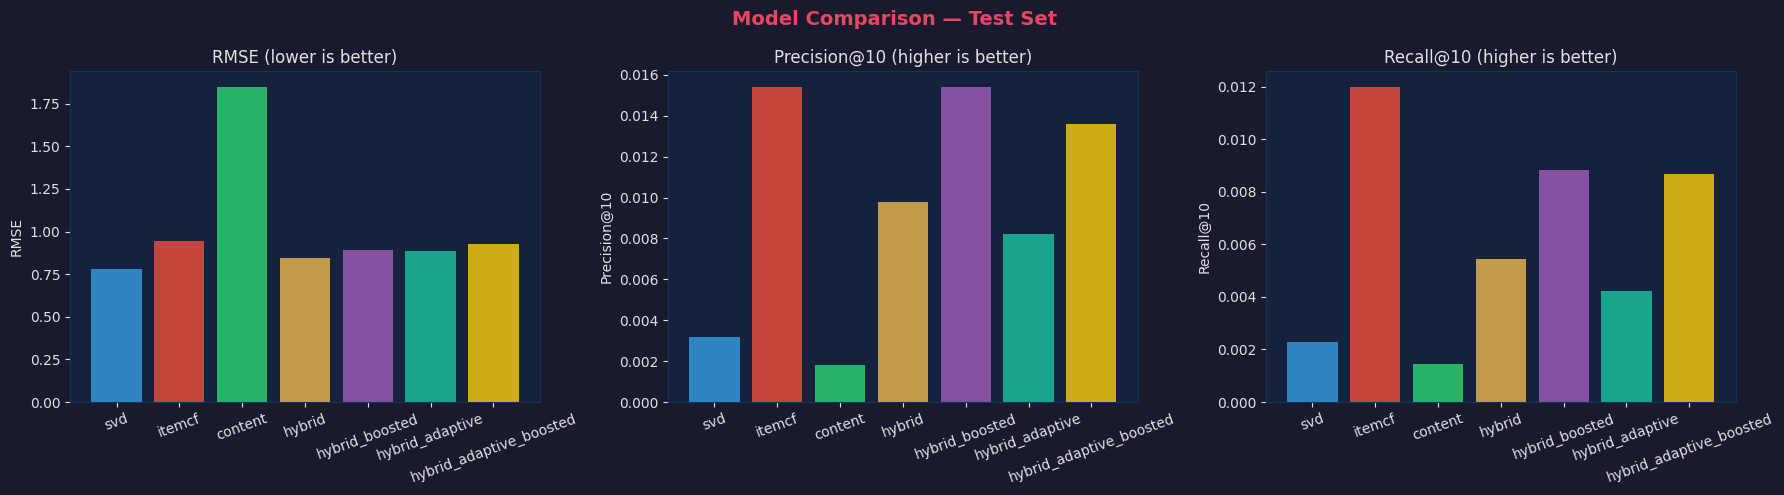

Training complete. Run app.py to start the web app.


In [21]:
import matplotlib.pyplot as plt

model_names = list(results.keys())
rmse_vals   = [results[m]['rmse'] for m in model_names]
p10_vals    = [results[m]['precision_10'] for m in model_names]
r10_vals    = [results[m]['recall_10'] for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison — Test Set', fontsize=14, fontweight='bold', color='#e94560')
fig.patch.set_facecolor('#1a1a2e')
colors = ['#3498db', '#e74c3c', '#2ecc71', '#e2b04a', '#9b59b6', '#1abc9c', '#f1c40f']

for ax in axes:
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='#e0e0e0')
    ax.spines[:].set_color('#0f3460')

axes[0].bar(model_names, rmse_vals, color=colors[:len(model_names)], alpha=0.85)
axes[0].set_title('RMSE (lower is better)', color='#e0e0e0')
axes[0].set_ylabel('RMSE', color='#e0e0e0')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(model_names, p10_vals, color=colors[:len(model_names)], alpha=0.85)
axes[1].set_title('Precision@10 (higher is better)', color='#e0e0e0')
axes[1].set_ylabel('Precision@10', color='#e0e0e0')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(model_names, r10_vals, color=colors[:len(model_names)], alpha=0.85)
axes[2].set_title('Recall@10 (higher is better)', color='#e0e0e0')
axes[2].set_ylabel('Recall@10', color='#e0e0e0')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('data/cleaning/viz_model_comparison.png', dpi=120,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Training complete. Run app.py to start the web app.')
